In [18]:
import pandas as pd
import numpy as np
import math
import random
import pickle
from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import CalibratedClassifierCV
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

MODELS_CACHE = {}

def main(year, sim_count):
    
    data = pd.read_csv("../../data/data_official.csv")
    
    if year not in MODELS_CACHE:
        try:
            with open(f'../RFmodels/rf_model_{year}.pkl', 'rb') as f:
                MODELS_CACHE[year] = pickle.load(f)
        except FileNotFoundError:
            raise ValueError(f"Model for year {year} not found. Please train it first.")
            
    model = MODELS_CACHE[year]
    
    data['Sim_Wins'] = [-1 for _ in range(len(data))]
    data['R68_win%'] = [1.0 for _ in range(len(data))]
    data['R64_win%'] = [0.0 for _ in range(len(data))]
    data['R32_win%'] = [0.0 for _ in range(len(data))]
    data['S16_win%'] = [0.0 for _ in range(len(data))]
    data['E8_win%'] = [0.0 for _ in range(len(data))]
    data['F4_win%'] = [0.0 for _ in range(len(data))]
    data['CG_win%'] = [0.0 for _ in range(len(data))]
    data['R68_opp'] = ["N/A" for _ in range(len(data))]
    data['R64_opp'] = ["N/A" for _ in range(len(data))]
    data['R32_opp'] = ["N/A" for _ in range(len(data))]
    data['S16_opp'] = ["N/A" for _ in range(len(data))]
    data['E8_opp'] = ["N/A" for _ in range(len(data))]
    data['F4_opp'] = ["N/A" for _ in range(len(data))]
    data['CG_opp'] = ["N/A" for _ in range(len(data))]
    
    i = 0
    
    sims = []
    scores = []
        
    while i < sim_count:
        
        sim_df = simulation(year, i, data, model)
        
        score = 0

        score = score + (10 * (len(sim_df[(sim_df["YEAR"] == year) & (sim_df["Wins"] > 0) & (sim_df["Sim_Wins"] > 0)])))
        score = score + (20 * (len(sim_df[(sim_df["YEAR"] == year) & (sim_df["Wins"] > 1) & (sim_df["Sim_Wins"] > 1)])))
        score = score + (40 * (len(sim_df[(sim_df["YEAR"] == year) & (sim_df["Wins"] > 2) & (sim_df["Sim_Wins"] > 2)])))
        score = score + (80 * (len(sim_df[(sim_df["YEAR"] == year) & (sim_df["Wins"] > 3) & (sim_df["Sim_Wins"] > 3)])))
        score = score + (160 * (len(sim_df[(sim_df["YEAR"] == year) & (sim_df["Wins"] > 4) & (sim_df["Sim_Wins"] > 4)])))
        score = score + (320 * (len(sim_df[(sim_df["YEAR"] == year) & (sim_df["Wins"] > 5) & (sim_df["Sim_Wins"] > 5)])))
        
        sims.append(sim_df)
        scores.append(score)
        i = i+1
                
    full_df = pd.concat(sims, axis=0).reset_index(drop=True)
    
    final_df = calc_outcome(full_df)
    
    final_df1 = final_df[['sim_num', 'QUAD ID', 'TEAM', 'SEED', 'Wins', 'Sim_Wins', 'R68_win%', 'R68_opp', 'R64_win%', 'R64_opp', 'R32_win%', 'R32_opp', 'S16_win%', 'S16_opp', 'E8_win%', 'E8_opp', 'F4_win%', 'F4_opp', 'CG_win%', 'CG_opp', 'Outcome_%']]
        
    return final_df1, scores

def simulation(year, sim_num, data, model):
    
    data = data.copy()
    
    data['sim_num'] = sim_num + 1
    
    df1 = region_simulation(data, year, 1, model)
    df1n = df1[df1["QUAD ID"] == 1]
    df2 = region_simulation(data, year, 2, model)
    df2n = df2[df2["QUAD ID"] == 2]
    df3 = region_simulation(data, year, 3, model)
    df3n = df3[df3["QUAD ID"] == 3]
    df4 = region_simulation(data, year, 4, model)
    df4n = df4[df4["QUAD ID"] == 4]
    
    df = pd.concat([df1n, df2n, df3n, df4n])
        
    df = final4(df, year, model)
    
    df = championship(df, year, model)
    
    df_year = df[df["YEAR"] == year]
    dfn = df_year[['sim_num', 'YEAR', 'QUAD ID', 'TEAM', 'SEED', 'Wins', 'Sim_Wins', 'R68_win%', 'R68_opp', 'R64_win%', 'R64_opp', 'R32_win%', 'R32_opp', 'S16_win%', 'S16_opp', 'E8_win%', 'E8_opp', 'F4_win%', 'F4_opp', 'CG_win%', 'CG_opp']]
                            
    return dfn

def region_simulation(data, year, quad, model):
    
    seeds = list(range(1,17))

    ###########################################################################
    # FIRST FOUR
    
    for seed in seeds:
    
        if data[(data["SEED"] == seed) & (data["YEAR"] == year) & (data["QUAD ID"] == quad)].shape[0] > 1:
            
            data = same_seed(data, year, quad, seed, model)
    ##########################################################################
    ##########################################################################
    # FIRST ROUND (R64)
        
    data = round64(data, year, quad, model)
    
    ##########################################################################
    ##########################################################################
    # SECOND ROUND (R32)
    
    data = round32(data, year, quad, model)
    
    ##########################################################################
    ##########################################################################
    # SWEET 16
    
    data = sweet16(data, year, quad, model)
    
    ##########################################################################
    ##########################################################################
    # ELITE 8
    
    data = elite8(data, year, quad, model)
    
    return data

def same_seed(data, year, quad, seed, model):
    
    subdf = data[(data["YEAR"] == year) & (data["QUAD ID"] == quad) & (data["SEED"] == seed)].copy()
    team0 = subdf.head(1)
    team0name = str(team0["TEAM"].iloc[0])
    team0index = team0["TEAM"].index
    team1 = subdf.tail(1)
    team1name = str(team1["TEAM"].iloc[0])
    team1index = team1["TEAM"].index
    
    perc = find_percentages(data, team0name, team1name, year, model)
    
    data.loc[team0index, "R68_win%"] = perc
    data.loc[team1index, "R68_win%"] = 1-perc
    data.loc[team0index, "R68_opp"] = team1name
    data.loc[team1index, "R68_opp"] = team0name
    
    winner = weighted_coin_flip(perc)

    if winner == 1:
        data.loc[team1index, "Sim_Wins"] = 0

    else:
        data.loc[team0index, "Sim_Wins"] = 0
        
    return data

def round64(data, year, quad, model):
    
    subdf = data[(data["YEAR"] == year) & (data["QUAD ID"] == quad) & (data["Sim_Wins"] == -1)]
    
    seeds1 = [1,2,3,4,5,6,7,8]
    seeds2 = [16,15,14,13,12,11,10,9]
    
    for i in range(0,8):
        
        rdf = subdf[(subdf["SEED"] == seeds1[i]) | (subdf["SEED"] == seeds2[i])]
        team0 = rdf.head(1)
        team0name = str(team0["TEAM"].iloc[0])
        team0index = team0["TEAM"].index
        team1 = rdf.tail(1)
        team1name = str(team1["TEAM"].iloc[0])
        team1index = team1["TEAM"].index
                
        perc = find_percentages(data, team0name, team1name, year, model)
        
        data.loc[team0index, "R64_win%"] = perc
        data.loc[team1index, "R64_win%"] = 1-perc
        data.loc[team0index, "R64_opp"] = team1name
        data.loc[team1index, "R64_opp"] = team0name

        winner = weighted_coin_flip(perc)
        
        if winner == 1:
            data.loc[team1index, "Sim_Wins"] = 0

        else:
            data.loc[team0index, "Sim_Wins"] = 0

    return data

def round32(data, year, quad, model):
    
    subdf = data[(data["YEAR"] == year) & (data["QUAD ID"] == quad) & (data["Sim_Wins"] == -1)]
    
    team0 = subdf[(subdf["SEED"] == 1) | (subdf["SEED"] == 16)]
    team0name = str(team0["TEAM"].iloc[0])
    team0index = team0["TEAM"].index
    team1 = subdf[(subdf["SEED"] == 8) | (subdf["SEED"] == 9)]
    team1name = str(team1["TEAM"].iloc[0])
    team1index = team1["TEAM"].index
    perc = find_percentages(data, team0name, team1name, year, model)
    data.loc[team0index, "R32_win%"] = perc
    data.loc[team1index, "R32_win%"] = 1-perc
    data.loc[team0index, "R32_opp"] = team1name
    data.loc[team1index, "R32_opp"] = team0name
    winner = weighted_coin_flip(perc)
    if winner == 1:
        data.loc[team1index, "Sim_Wins"] = 1
    else:
        data.loc[team0index, "Sim_Wins"] = 1
    
    team0 = subdf[(subdf["SEED"] == 5) | (subdf["SEED"] == 12)]
    team0name = str(team0["TEAM"].iloc[0])
    team0index = team0["TEAM"].index
    team1 = subdf[(subdf["SEED"] == 4) | (subdf["SEED"] == 13)]
    team1name = str(team1["TEAM"].iloc[0])
    team1index = team1["TEAM"].index
    perc = find_percentages(data, team0name, team1name, year, model)
    data.loc[team0index, "R32_win%"] = perc
    data.loc[team1index, "R32_win%"] = 1-perc
    data.loc[team0index, "R32_opp"] = team1name
    data.loc[team1index, "R32_opp"] = team0name
    winner = weighted_coin_flip(perc)
    if winner == 1:
        data.loc[team1index, "Sim_Wins"] = 1
    else:
        data.loc[team0index, "Sim_Wins"] = 1
    
    team0 = subdf[(subdf["SEED"] == 6) | (subdf["SEED"] == 11)]
    team0name = str(team0["TEAM"].iloc[0])
    team0index = team0["TEAM"].index
    team1 = subdf[(subdf["SEED"] == 3) | (subdf["SEED"] == 14)]
    team1name = str(team1["TEAM"].iloc[0])
    team1index = team1["TEAM"].index
    perc = find_percentages(data, team0name, team1name, year, model)
    data.loc[team0index, "R32_win%"] = perc
    data.loc[team1index, "R32_win%"] = 1-perc
    data.loc[team0index, "R32_opp"] = team1name
    data.loc[team1index, "R32_opp"] = team0name
    winner = weighted_coin_flip(perc)
    if winner == 1:
        data.loc[team1index, "Sim_Wins"] = 1
    else:
        data.loc[team0index, "Sim_Wins"] = 1
    
    team0 = subdf[(subdf["SEED"] == 7) | (subdf["SEED"] == 10)]
    team0name = str(team0["TEAM"].iloc[0])
    team0index = team0["TEAM"].index
    team1 = subdf[(subdf["SEED"] == 2) | (subdf["SEED"] == 15)]
    team1name = str(team1["TEAM"].iloc[0])
    team1index = team1["TEAM"].index
    perc = find_percentages(data, team0name, team1name, year, model)
    data.loc[team0index, "R32_win%"] = perc
    data.loc[team1index, "R32_win%"] = 1-perc
    data.loc[team0index, "R32_opp"] = team1name
    data.loc[team1index, "R32_opp"] = team0name
    winner = weighted_coin_flip(perc)
    if winner == 1:
        data.loc[team1index, "Sim_Wins"] = 1
    else:
        data.loc[team0index, "Sim_Wins"] = 1
        
    return data

def sweet16(data, year, quad, model):
    
    subdf = data[(data["YEAR"] == year) & (data["QUAD ID"] == quad) & (data["Sim_Wins"] == -1)]
    
    options1 = [1,8,9,16]
    for i in options1:
        if not subdf[subdf["SEED"] == i].empty:
            team0 = subdf[subdf["SEED"] == i]
            break
    team0name = str(team0["TEAM"].iloc[0])
    team0index = team0["TEAM"].index
    options2 = [4,5,12,13]
    for i in options2:
        if not subdf[subdf["SEED"] == i].empty:
            team1 = subdf[subdf["SEED"] == i]
            break
    team1name = str(team1["TEAM"].iloc[0])
    team1index = team1["TEAM"].index
    perc = find_percentages(data, team0name, team1name, year, model)
    data.loc[team0index, "S16_win%"] = perc
    data.loc[team1index, "S16_win%"] = 1-perc
    data.loc[team0index, "S16_opp"] = team1name
    data.loc[team1index, "S16_opp"] = team0name
    winner = weighted_coin_flip(perc)
    if winner == 1:
        data.loc[team1index, "Sim_Wins"] = 2
    else:
        data.loc[team0index, "Sim_Wins"] = 2

    options3 = [3,6,11,14]
    for i in options3:
        if not subdf[subdf["SEED"] == i].empty:
            team0 = subdf[subdf["SEED"] == i]
            break
    team0name = str(team0["TEAM"].iloc[0])
    team0index = team0["TEAM"].index
    options4 = [2,7,10,15]
    for i in options4:
        if not subdf[subdf["SEED"] == i].empty:
            team1 = subdf[subdf["SEED"] == i]
            break
    team1name = str(team1["TEAM"].iloc[0])
    team1index = team1["TEAM"].index
    perc = find_percentages(data, team0name, team1name, year, model)
    data.loc[team0index, "S16_win%"] = perc
    data.loc[team1index, "S16_win%"] = 1-perc
    data.loc[team0index, "S16_opp"] = team1name
    data.loc[team1index, "S16_opp"] = team0name
    winner = weighted_coin_flip(perc)
    if winner == 1:
        data.loc[team1index, "Sim_Wins"] = 2
    else:
        data.loc[team0index, "Sim_Wins"] = 2  
    
    return data

def elite8(data, year, quad, model):
    
    subdf = data[(data["YEAR"] == year) & (data["QUAD ID"] == quad) & (data["Sim_Wins"] == -1)]
    
    options1 = [1,4,5,8,9,12,13,16]
    for i in options1:
        if not subdf[subdf["SEED"] == i].empty:
            team0 = subdf[subdf["SEED"] == i]
            break
    team0name = str(team0["TEAM"].iloc[0])
    team0index = team0["TEAM"].index
    
    options2 = [2,3,6,7,10,11,14,15]
    for i in options2:
        if not subdf[subdf["SEED"] == i].empty:
            team1 = subdf[subdf["SEED"] == i]
            break
    team1name = str(team1["TEAM"].iloc[0])
    team1index = team1["TEAM"].index
    
    perc = find_percentages(data, team0name, team1name, year, model)
    data.loc[team0index, "E8_win%"] = perc
    data.loc[team1index, "E8_win%"] = 1-perc
    data.loc[team0index, "E8_opp"] = team1name
    data.loc[team1index, "E8_opp"] = team0name
    winner = weighted_coin_flip(perc)
    if winner == 1:
        data.loc[team1index, "Sim_Wins"] = 3
    else:
        data.loc[team0index, "Sim_Wins"] = 3
        
    return data

def final4(data, year, model):
    
    subdf = data[(data["YEAR"] == year) & (data["Sim_Wins"] == -1)]
    
    team0 = subdf[subdf["QUAD ID"] == 1]
    team0name = str(team0["TEAM"].iloc[0])
    team0index = team0["TEAM"].index
        
    team1 = subdf[subdf["QUAD ID"] == 2]
    team1name = str(team1["TEAM"].iloc[0])
    team1index = team1["TEAM"].index
    
    perc = find_percentages(data, team0name, team1name, year, model)
    data.loc[team0index, "F4_win%"] = perc
    data.loc[team1index, "F4_win%"] = 1-perc
    data.loc[team0index, "F4_opp"] = team1name
    data.loc[team1index, "F4_opp"] = team0name
    winner = weighted_coin_flip(perc)
    if winner == 1:
        data.loc[team1index, "Sim_Wins"] = 4
    else:
        data.loc[team0index, "Sim_Wins"] = 4
        
    team0 = subdf[subdf["QUAD ID"] == 3]
    team0name = str(team0["TEAM"].iloc[0])
    team0index = team0["TEAM"].index
        
    team1 = subdf[subdf["QUAD ID"] == 4]
    team1name = str(team1["TEAM"].iloc[0])
    team1index = team1["TEAM"].index
        
    perc = find_percentages(data, team0name, team1name, year, model)
    data.loc[team0index, "F4_win%"] = perc
    data.loc[team1index, "F4_win%"] = 1-perc
    data.loc[team0index, "F4_opp"] = team1name
    data.loc[team1index, "F4_opp"] = team0name
    winner = weighted_coin_flip(perc)
    if winner == 1:
        data.loc[team1index, "Sim_Wins"] = 4
    else:
        data.loc[team0index, "Sim_Wins"] = 4    
    
    return data

def championship(data, year, model):
    
    subdf = data[(data["YEAR"] == year) & (data["Sim_Wins"] == -1)]
    
    team0 = subdf.head(1)
    team0name = str(team0["TEAM"].iloc[0])
    team0index = team0["TEAM"].index
    team1 = subdf.tail(1)
    team1name = str(team1["TEAM"].iloc[0])
    team1index = team1["TEAM"].index
    
    perc = find_percentages(data, team0name, team1name, year, model)
    data.loc[team0index, "CG_win%"] = perc
    data.loc[team1index, "CG_win%"] = 1-perc
    data.loc[team0index, "CG_opp"] = team1name
    data.loc[team1index, "CG_opp"] = team0name
    winner = weighted_coin_flip(perc)
    if winner == 1:
        data.loc[team1index, "Sim_Wins"] = 5
        data.loc[team0index, "Sim_Wins"] = 6
    else:
        data.loc[team0index, "Sim_Wins"] = 5
        data.loc[team1index, "Sim_Wins"] = 6    
    
    return data

def game_style(df, team0, team1, year):
    
    cols = ['KADJ T',
       'KADJ O', 'KADJ D', 'EFG%', 'EFG%D', 'FTR', 'FTRD', 'TOV%',
       'TOV%D', 'OREB%', 'DREB%', '2PT%', '2PT%D', '3PT%', '3PT%D', 'AST%',
       '2PTR', '3PTR', '2PTRD', '3PTRD', 'EFF HGT', 'EXP', 'FT%',
       'ELITE SOS']
    
    t0 = df[(df["TEAM"] == team0) & (df["YEAR"] == year)].reset_index(drop=True)
    t1 = df[(df["TEAM"] == team1) & (df["YEAR"] == year)].reset_index(drop=True)
    
    game = pd.DataFrame()
    
    for col in cols:
        game[col] = t0[col] - t1[col]
    game.insert(0, "YEAR", year)
    game.insert(1, "Team0", t0["TEAM"])
    game.insert(2, "Team1", t1["TEAM"])
    
    return game

def find_percentages(df, team0, team1, year, model):
    
    features = ['KADJ T', 'KADJ O', 'KADJ D', 'EFG%', 'EFG%D', 'FTR', 'FTRD', 
                'TOV%', 'TOV%D', 'OREB%', 'DREB%', '2PT%', '2PT%D', '3PT%', 
                '3PT%D', 'AST%', '2PTR', '3PTR', '2PTRD', '3PTRD', 'EFF HGT', 
                'EXP', 'FT%', 'ELITE SOS']
    
    game_01 = game_style(df, team0, team1, year)
    game_10 = game_style(df, team1, team0, year)
    
    X_test_01 = game_01[features].values
    X_test_10 = game_10[features].values
    
    probs_01 = model.predict_proba(X_test_01)[0]
    probs_10 = model.predict_proba(X_test_10)[0]
    
    team0_win_prob = (probs_01[0] + probs_10[1]) / 2
    team1_win_prob = (probs_01[1] + probs_10[0]) / 2
    
    return team0_win_prob

def weighted_coin_flip(perc1):
    
    num = random.random()
    
    if num < perc1:
        return 1
    
    else:
        return 2
    
def calc_outcome(df):
    
    df['Outcome_%'] = [0 for _ in range(len(df))]
    
    df.loc[df['Sim_Wins'] == 6, 'Outcome_%'] = df['R68_win%'] * df['R64_win%'] * df['R32_win%'] * df['S16_win%'] * df['E8_win%'] * df['F4_win%'] * df['CG_win%']
    df.loc[df['Sim_Wins'] == 5, 'Outcome_%'] = df['R68_win%'] * df['R64_win%'] * df['R32_win%'] * df['S16_win%'] * df['E8_win%'] * df['F4_win%'] * (1-df['CG_win%'])
    df.loc[df['Sim_Wins'] == 4, 'Outcome_%'] = df['R68_win%'] * df['R64_win%'] * df['R32_win%'] * df['S16_win%'] * df['E8_win%'] * (1-df['F4_win%'])
    df.loc[df['Sim_Wins'] == 3, 'Outcome_%'] = df['R68_win%'] * df['R64_win%'] * df['R32_win%'] * df['S16_win%'] * (1-df['E8_win%'])
    df.loc[df['Sim_Wins'] == 2, 'Outcome_%'] = df['R68_win%'] * df['R64_win%'] * df['R32_win%'] * (1-df['S16_win%'])
    df.loc[df['Sim_Wins'] == 1, 'Outcome_%'] = df['R68_win%'] * df['R64_win%'] * (1-df['R32_win%'])
    df.loc[(df['Sim_Wins'] == 0) & (df['R64_win%'] != 0), 'Outcome_%'] = df['R68_win%'] * (1-df['R64_win%'])
    df.loc[(df['Sim_Wins'] == 0) & (df['R64_win%'] == 0), 'Outcome_%'] = (1-df['R68_win%'])
    
    df['R68_win%'] = df['R68_win%'].mul(100).round(3)
    df['R64_win%'] = df['R64_win%'].mul(100).round(3)
    df['R32_win%'] = df['R32_win%'].mul(100).round(3)
    df['S16_win%'] = df['S16_win%'].mul(100).round(3)
    df['E8_win%'] = df['E8_win%'].mul(100).round(3)
    df['F4_win%'] = df['F4_win%'].mul(100).round(3)
    df['CG_win%'] = df['CG_win%'].mul(100).round(3)
    df['Outcome_%'] = df['Outcome_%'].mul(100).round(3)
        
    return df

In [3]:
df, scores = main(2025, 1000)

In [4]:
import numpy as np

top_5_indices = np.argsort(scores)[-5:][::-1]  
top_5 = [(i+1, scores[i]) for i in top_5_indices] 

bottom_5_indices = np.argsort(scores)[:5]  
bottom_5 = [(i+1, scores[i]) for i in bottom_5_indices]

avg_score = np.mean(scores)

print("=" * 40)
print("TOP 5 SCORES")
print("=" * 40)
for sim_num, score in top_5:
    print(f"Sim #{sim_num}: {score}")

print("\n" + "=" * 40)
print("BOTTOM 5 SCORES")
print("=" * 40)
for sim_num, score in bottom_5:
    print(f"Sim #{sim_num}: {score}")

print("\n" + "=" * 40)
print(f"AVERAGE SCORE: {avg_score:.2f}")
print("=" * 40)

TOP 5 SCORES
Sim #802: 1680
Sim #780: 1660
Sim #977: 1650
Sim #740: 1580
Sim #107: 1550

BOTTOM 5 SCORES
Sim #167: 320
Sim #789: 340
Sim #204: 340
Sim #1000: 350
Sim #844: 360

AVERAGE SCORE: 843.67


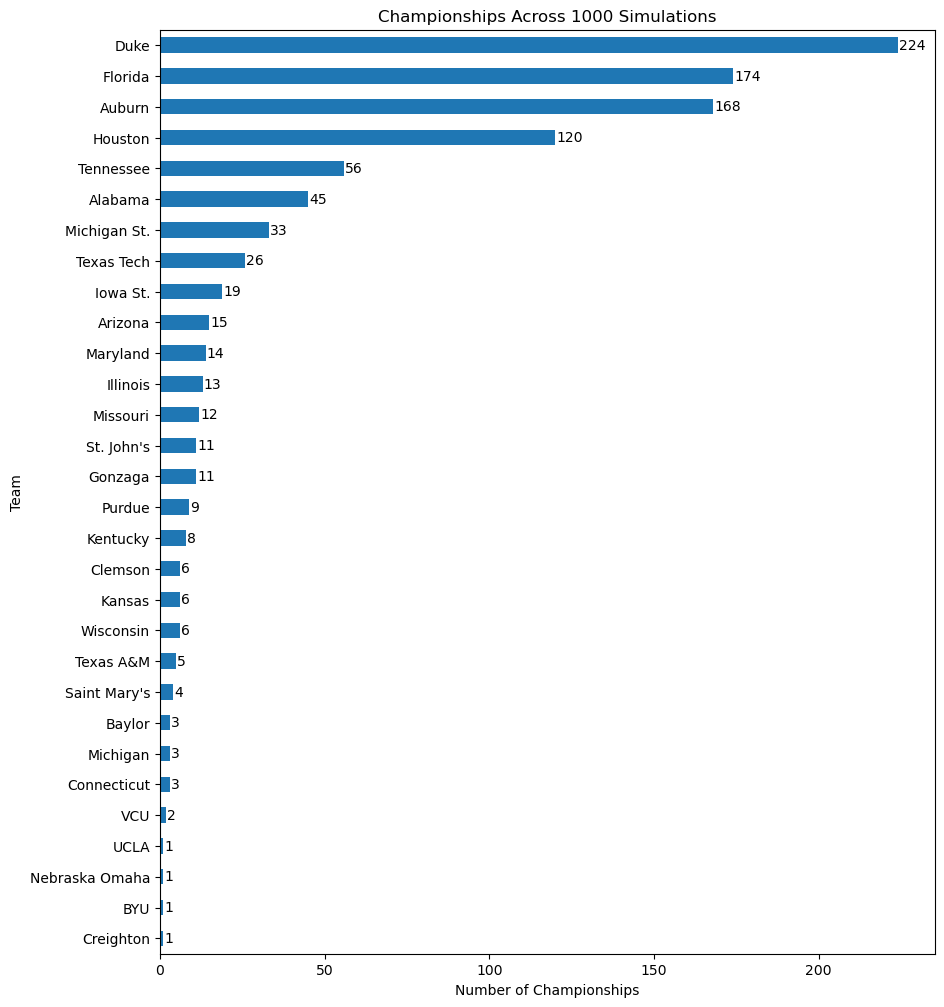

In [10]:
import matplotlib.pyplot as plt

champ_counts = df.loc[df['Sim_Wins'] == 6, 'TEAM'].value_counts()

ax = champ_counts[::-1].plot(kind='barh', figsize=(10,12))

plt.title("Championships Across 1000 Simulations")
plt.ylabel("Team")
plt.xlabel("Number of Championships")
plt.yticks(rotation=0)

for i, v in enumerate(champ_counts[::-1]):
    ax.text(v + 0.3, i, str(v), va='center')

plt.show()

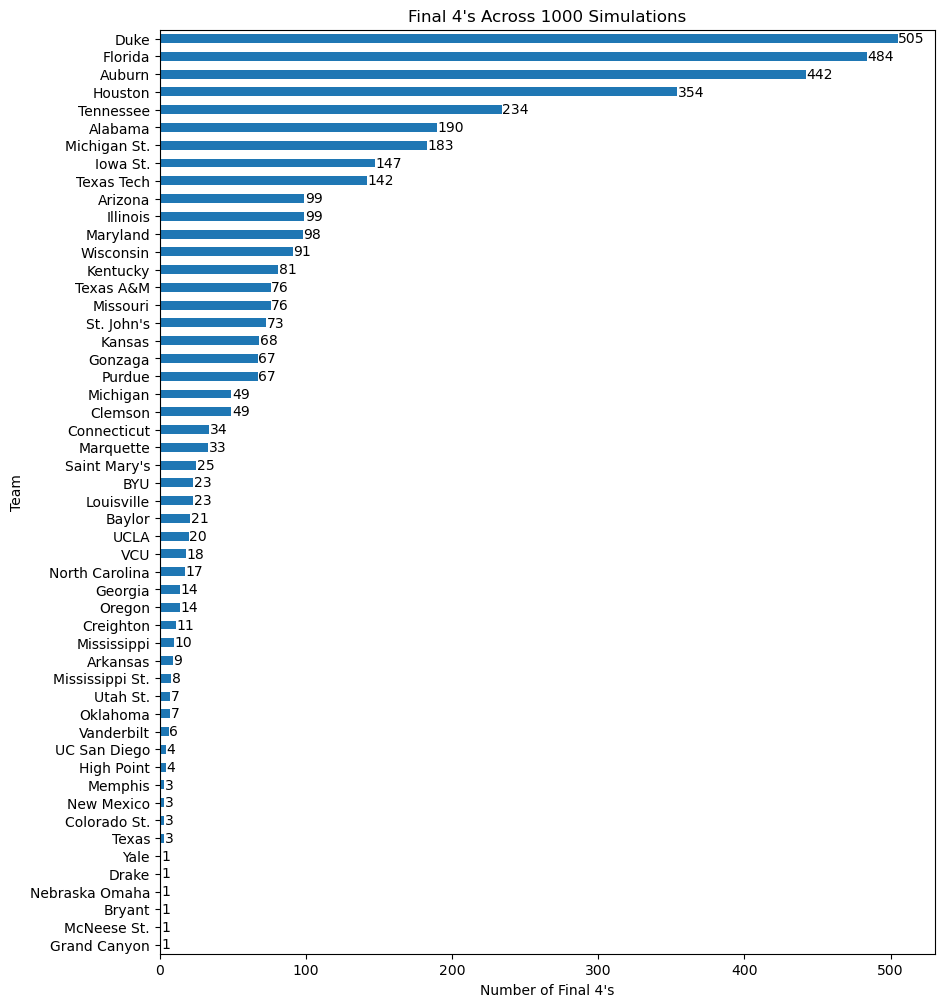

In [11]:
import matplotlib.pyplot as plt

champ_counts = df.loc[df['Sim_Wins'] >= 4, 'TEAM'].value_counts()

ax = champ_counts[::-1].plot(kind='barh', figsize=(10,12))

plt.title("Final 4's Across 1000 Simulations")
plt.ylabel("Team")
plt.xlabel("Number of Final 4's")
plt.yticks(rotation=0)

for i, v in enumerate(champ_counts[::-1]):
    ax.text(v + 0.3, i, str(v), va='center')

plt.show()

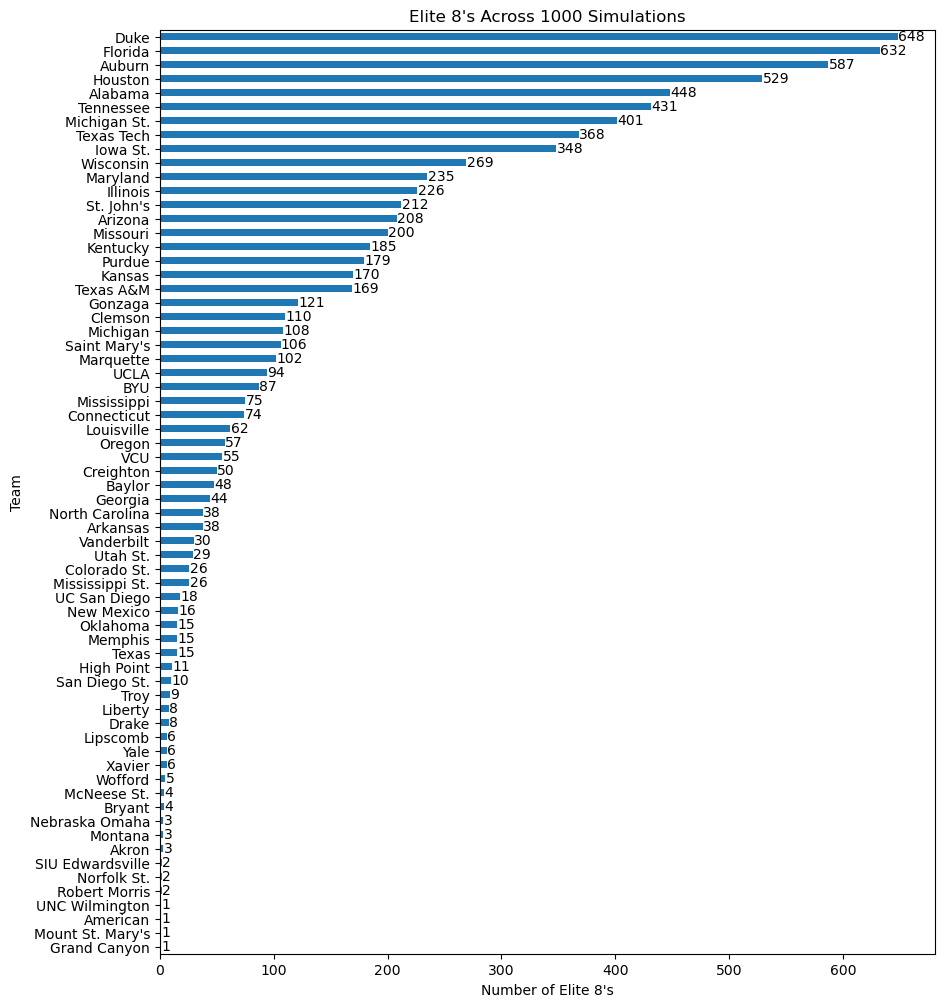

In [14]:
import matplotlib.pyplot as plt

champ_counts = df.loc[df['Sim_Wins'] >= 3, 'TEAM'].value_counts()

ax = champ_counts[::-1].plot(kind='barh', figsize=(10,12))

plt.title("Elite 8's Across 1000 Simulations")
plt.ylabel("Team")
plt.xlabel("Number of Elite 8's")
plt.yticks(rotation=0)

for i, v in enumerate(champ_counts[::-1]):
    ax.text(v + 0.3, i, str(v), va='center')

plt.show()

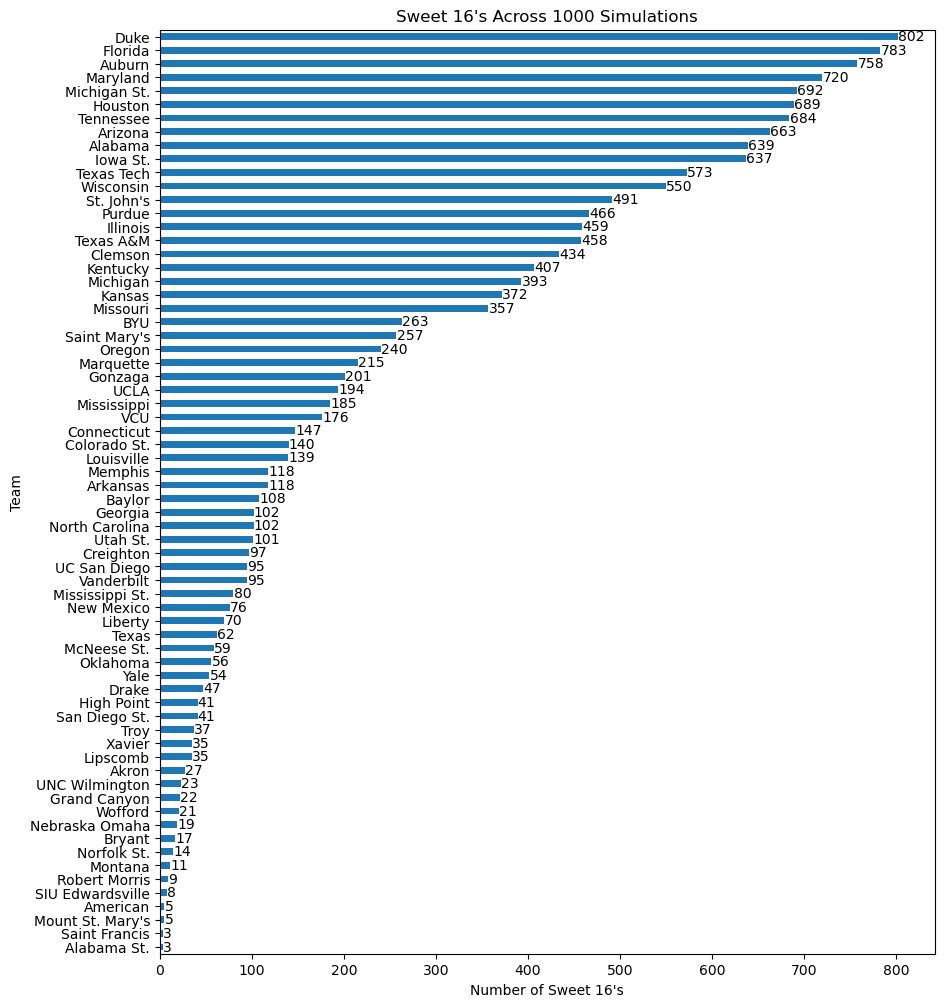

In [12]:
import matplotlib.pyplot as plt

champ_counts = df.loc[df['Sim_Wins'] >= 2, 'TEAM'].value_counts()

ax = champ_counts[::-1].plot(kind='barh', figsize=(10,12))

plt.title("Sweet 16's Across 1000 Simulations")
plt.ylabel("Team")
plt.xlabel("Number of Sweet 16's")
plt.yticks(rotation=0)

for i, v in enumerate(champ_counts[::-1]):
    ax.text(v + 0.3, i, str(v), va='center')

plt.show()

In [8]:
pd.set_option('display.max_columns', None)
df.sort_values("Outcome_%", ascending=True).head(25)

,sim_num,QUAD ID,TEAM,SEED,Wins,Sim_Wins,R68_win%,R68_opp,R64_win%,R64_opp,R32_win%,R32_opp,S16_win%,S16_opp,E8_win%,E8_opp,F4_win%,F4_opp,CG_win%,CG_opp,Outcome_%
928,14,3,Nebraska Omaha,15,0,6,100.000,N/A,12.763,St. John's,11.625,Kansas,8.861,Texas Tech,9.659,Connecticut,9.317,Michigan St.,10.053,Houston,0.000
16999,250,4,Yale,13,0,5,100.000,N/A,21.646,Texas A&M,18.976,Michigan,11.938,Auburn,21.002,Marquette,9.566,Florida,14.989,Alabama,0.008
32148,473,4,Bryant,15,0,4,100.000,N/A,11.574,Michigan St.,13.434,Marquette,11.937,Iowa St.,10.394,Auburn,15.599,Connecticut,0.000,N/A,0.016
56991,839,1,McNeese St.,12,1,5,100.000,N/A,19.850,Clemson,23.037,Purdue,11.281,Houston,13.833,Tennessee,28.066,Oregon,9.654,Florida,0.018
2451,37,1,High Point,13,0,5,100.000,N/A,19.655,Purdue,18.631,Clemson,28.727,Georgia,34.181,Texas,9.047,Duke,11.540,Auburn,0.029
67563,994,3,Grand Canyon,13,0,4,100.000,N/A,11.050,Maryland,22.971,Colorado St.,8.237,Florida,19.337,Missouri,11.230,Iowa St.,0.000,N/A,0.036
61975,912,2,Mount St. Mary's,16,0,3,53.196,American,7.367,Duke,11.990,Baylor,9.684,Arizona,10.302,Alabama,0.000,N/A,0.000,N/A,0.041
59357,873,4,New Mexico,10,1,5,100.000,N/A,31.843,Marquette,16.691,Michigan St.,45.940,San Diego St.,13.771,Auburn,23.484,Texas Tech,26.741,Gonzaga,0.058
41329,608,4,Creighton,9,1,5,100.000,N/A,38.657,Louisville,16.501,Auburn,41.981,Texas A&M,27.890,Michigan St.,16.275,Florida,45.082,Saint Mary's,0.067
55507,817,2,American,16,0,3,46.804,Mount St. Mary's,6.961,Duke,10.108,Baylor,22.729,Akron,9.469,Alabama,0.000,N/A,0.000,N/A,0.068


In [9]:
df[df["sim_num"] == 802].sort_values("Sim_Wins", ascending=False).head(32)

,sim_num,QUAD ID,TEAM,SEED,Wins,Sim_Wins,R68_win%,R68_opp,R64_win%,R64_opp,R32_win%,R32_opp,S16_win%,S16_opp,E8_win%,E8_opp,F4_win%,F4_opp,CG_win%,CG_opp,Outcome_%
54506,802,3,Florida,1,6,6,100.0,N/A,92.276,Norfolk St.,86.160,Oklahoma,76.500,Maryland,77.521,Texas Tech,50.587,Auburn,50.42,Houston,12.026
54472,802,1,Houston,1,5,5,100.0,N/A,90.445,SIU Edwardsville,71.186,Gonzaga,67.683,Purdue,62.921,Tennessee,44.133,Duke,49.58,Florida,6.101
54491,802,2,Duke,1,4,4,100.0,N/A,93.039,American,85.555,Mississippi St.,85.590,Oregon,70.708,Alabama,55.867,Houston,0.00,N/A,21.260
54519,802,4,Auburn,1,4,4,100.0,N/A,91.734,Alabama St.,83.682,Louisville,79.137,Michigan,82.967,Marquette,49.413,Florida,0.00,N/A,25.497
54525,802,4,Marquette,7,0,3,100.0,N/A,68.157,New Mexico,27.939,Michigan St.,53.152,Mississippi,17.033,Auburn,0.000,N/A,0.00,N/A,8.398
54486,802,2,Alabama,2,3,3,100.0,N/A,88.796,Robert Morris,85.807,Vanderbilt,66.112,Wisconsin,29.292,Duke,0.000,N/A,0.00,N/A,35.618
54478,802,1,Tennessee,2,3,3,100.0,N/A,88.696,Wofford,79.272,UCLA,60.557,Illinois,37.079,Houston,0.000,N/A,0.00,N/A,26.791
54516,802,3,Texas Tech,3,3,3,100.0,N/A,88.295,UNC Wilmington,60.773,Missouri,57.993,Kansas,22.479,Florida,0.000,N/A,0.00,N/A,24.124
54476,802,1,Purdue,4,2,2,100.0,N/A,80.345,High Point,76.963,McNeese St.,32.317,Houston,0.000,N/A,0.000,N/A,0.00,N/A,41.853
54508,802,3,Kansas,7,0,2,100.0,N/A,71.721,Arkansas,50.311,St. John's,42.007,Texas Tech,0.000,N/A,0.000,N/A,0.00,N/A,20.926


In [16]:
df[df["sim_num"] == 14].sort_values("Sim_Wins", ascending=False).head(32)

,sim_num,QUAD ID,TEAM,SEED,Wins,Sim_Wins,R68_win%,R68_opp,R64_win%,R64_opp,R32_win%,R32_opp,S16_win%,S16_opp,E8_win%,E8_opp,F4_win%,F4_opp,CG_win%,CG_opp,Outcome_%
928,14,3,Nebraska Omaha,15,0,6,100.000,N/A,12.763,St. John's,11.625,Kansas,8.861,Texas Tech,9.659,Connecticut,9.317,Michigan St.,10.053,Houston,0.000
888,14,1,Houston,1,5,5,100.000,N/A,90.445,SIU Edwardsville,80.110,Georgia,67.683,Purdue,62.921,Tennessee,44.133,Duke,89.947,Nebraska Omaha,1.369
907,14,2,Duke,1,4,4,100.000,N/A,92.633,Mount St. Mary's,83.773,Baylor,76.368,Arizona,80.442,BYU,55.867,Houston,0.000,N/A,21.039
943,14,4,Michigan St.,2,3,4,100.000,N/A,88.426,Bryant,83.309,New Mexico,79.061,San Diego St.,72.110,Creighton,90.683,Nebraska Omaha,0.000,N/A,3.913
894,14,1,Tennessee,2,3,3,100.000,N/A,88.696,Wofford,79.272,UCLA,86.188,Xavier,37.079,Houston,0.000,N/A,0.000,N/A,38.130
920,14,3,Connecticut,8,1,3,100.000,N/A,57.092,Oklahoma,15.654,Florida,42.932,Maryland,90.341,Nebraska Omaha,0.000,N/A,0.000,N/A,0.371
937,14,4,Creighton,9,1,3,100.000,N/A,38.657,Louisville,16.501,Auburn,41.981,Texas A&M,27.890,Michigan St.,0.000,N/A,0.000,N/A,1.931
906,14,2,BYU,6,2,3,100.000,N/A,52.436,VCU,40.712,Wisconsin,66.638,Vanderbilt,19.558,Duke,0.000,N/A,0.000,N/A,11.443
892,14,1,Purdue,4,2,2,100.000,N/A,80.345,High Point,53.424,Clemson,32.317,Houston,0.000,N/A,0.000,N/A,0.000,N/A,29.052
925,14,3,Maryland,4,2,2,100.000,N/A,88.950,Grand Canyon,81.115,Memphis,57.068,Connecticut,0.000,N/A,0.000,N/A,0.000,N/A,30.977


In [112]:
from itertools import zip_longest
teams = list(df["TEAM"].unique())
cc = []
for team in teams:
    x = df[(df["TEAM"] == team) & (df["Sim_Wins"] == 6)]
    dfx = {}
    dfx["TEAM"] = team
    dfx["Seed"] = np.mean(x["SEED"])
    if len(x) == 0:
        dfx["Seed"] = np.mean(df[(df["TEAM"] == team)]["SEED"])
    dfx["count"] = len(x)
    cc.append(dfx)
counts = pd.DataFrame(cc).sort_values(["count", "Seed"], ascending=[False, True])
teams1 = list(counts["TEAM"])
rows = []
for team in teams1:
    count = counts[counts["TEAM"] == team]["count"].iloc[0]
    perc = round((count / 1000) * 100, 3)
    rows.append(f"{team:<17} {count:>3} --> {perc:>3}%")
col_size = 23
cols = [rows[i:i+col_size] for i in range(0, len(rows), col_size)]
print("Championships by Team for 1000 Simulations\n")
for row_group in zip_longest(*cols, fillvalue=""):
    print("   ".join(f"{cell:<40}" for cell in row_group))

Championships by Team for 1000 Simulations

Duke              224 --> 22.4%            Connecticut         3 --> 0.3%             San Diego St.       0 --> 0.0%          
Florida           174 --> 17.4%            Baylor              3 --> 0.3%             McNeese St.         0 --> 0.0%          
Auburn            168 --> 16.8%            VCU                 2 --> 0.2%             Liberty             0 --> 0.0%          
Houston           120 --> 12.0%            BYU                 1 --> 0.1%             Colorado St.        0 --> 0.0%          
Tennessee          56 --> 5.6%             UCLA                1 --> 0.1%             UC San Diego        0 --> 0.0%          
Alabama            45 --> 4.5%             Creighton           1 --> 0.1%             High Point          0 --> 0.0%          
Michigan St.       33 --> 3.3%             Nebraska Omaha      1 --> 0.1%             Akron               0 --> 0.0%          
Texas Tech         26 --> 2.6%             Oregon              0 --

In [115]:
teams = list(df["TEAM"].unique())
cc = []
for team in teams:
    x = df[(df["TEAM"] == team) & (df["Sim_Wins"] >= 4)]
    dfx = {}
    dfx["TEAM"] = team
    dfx["Seed"] = np.mean(x["SEED"])
    if len(x) == 0:
        dfx["Seed"] = np.mean(df[(df["TEAM"] == team)]["SEED"])
    dfx["count"] = len(x)
    cc.append(dfx)
counts = pd.DataFrame(cc).sort_values(["count", "Seed"], ascending=[False, True])
teams1 = list(counts["TEAM"])
rows = []
for team in teams1:
    count = counts[counts["TEAM"] == team]["count"].iloc[0]
    perc = round((count / 1000) * 100, 3)
    rows.append(f"{team:<17} {count:>3} --> {perc:>3}%")
col_size = 23
cols = [rows[i:i+col_size] for i in range(0, len(rows), col_size)]
print("Final 4's by Team for 1000 Simulations\n")
for row_group in zip_longest(*cols, fillvalue=""):
    print("   ".join(f"{cell:<40}" for cell in row_group))

Final 4's by Team for 1000 Simulations

Duke              505 --> 50.5%            Marquette          33 --> 3.3%             Drake               1 --> 0.1%          
Florida           484 --> 48.4%            Saint Mary's       25 --> 2.5%             McNeese St.         1 --> 0.1%          
Auburn            442 --> 44.2%            BYU                23 --> 2.3%             Grand Canyon        1 --> 0.1%          
Houston           354 --> 35.4%            Louisville         23 --> 2.3%             Yale                1 --> 0.1%          
Tennessee         234 --> 23.4%            Baylor             21 --> 2.1%             Nebraska Omaha      1 --> 0.1%          
Alabama           190 --> 19.0%            UCLA               20 --> 2.0%             Bryant              1 --> 0.1%          
Michigan St.      183 --> 18.3%            VCU                18 --> 1.8%             Xavier              0 --> 0.0%          
Iowa St.          147 --> 14.7%            North Carolina     17 --> 1.

In [129]:
teams = list(df["TEAM"].unique())
cc = []
for team in teams:
    x = df[(df["TEAM"] == team) & (df["Sim_Wins"] >= 3)]
    dfx = {}
    dfx["TEAM"] = team
    dfx["Seed"] = np.mean(x["SEED"])
    if len(x) == 0:
        dfx["Seed"] = np.mean(df[(df["TEAM"] == team)]["SEED"])
    dfx["count"] = len(x)
    cc.append(dfx)
counts = pd.DataFrame(cc).sort_values(["count", "Seed"], ascending=[False, True])
teams1 = list(counts["TEAM"])
rows = []
for team in teams1:
    count = counts[counts["TEAM"] == team]["count"].iloc[0]
    perc = round((count / 1000) * 100, 3)
    rows.append(f"{team:<17} {count:>3} --> {perc:>3}%")
col_size = 23
cols = [rows[i:i+col_size] for i in range(0, len(rows), col_size)]
print("Elite 8's by Team for 1000 Simulations\n")
for row_group in zip_longest(*cols, fillvalue=""):
    print("   ".join(f"{cell:<40}" for cell in row_group))

Elite 8's by Team for 1000 Simulations

Duke              648 --> 64.8%            Marquette         102 --> 10.2%            San Diego St.      10 --> 1.0%          
Florida           632 --> 63.2%            UCLA               94 --> 9.4%             Troy                9 --> 0.9%          
Auburn            587 --> 58.7%            BYU                87 --> 8.7%             Drake               8 --> 0.8%          
Houston           529 --> 52.9%            Mississippi        75 --> 7.5%             Liberty             8 --> 0.8%          
Alabama           448 --> 44.8%            Connecticut        74 --> 7.4%             Xavier              6 --> 0.6%          
Tennessee         431 --> 43.1%            Louisville         62 --> 6.2%             Yale                6 --> 0.6%          
Michigan St.      401 --> 40.1%            Oregon             57 --> 5.7%             Lipscomb            6 --> 0.6%          
Texas Tech        368 --> 36.8%            VCU                55 --> 5.

In [116]:
teams = list(df["TEAM"].unique())
cc = []
for team in teams:
    x = df[(df["TEAM"] == team) & (df["Sim_Wins"] >= 2)]
    dfx = {}
    dfx["TEAM"] = team
    dfx["Seed"] = np.mean(x["SEED"])
    if len(x) == 0:
        dfx["Seed"] = np.mean(df[(df["TEAM"] == team)]["SEED"])
    dfx["count"] = len(x)
    cc.append(dfx)
counts = pd.DataFrame(cc).sort_values(["count", "Seed"], ascending=[False, True])
teams1 = list(counts["TEAM"])
rows = []
for team in teams1:
    count = counts[counts["TEAM"] == team]["count"].iloc[0]
    perc = round((count / 1000) * 100, 3)
    rows.append(f"{team:<17} {count:>3} --> {perc:>3}%")
col_size = 23
cols = [rows[i:i+col_size] for i in range(0, len(rows), col_size)]
print("Sweet 16's by Team for 1000 Simulations\n")
for row_group in zip_longest(*cols, fillvalue=""):
    print("   ".join(f"{cell:<40}" for cell in row_group))

Sweet 16's by Team for 1000 Simulations

Duke              802 --> 80.2%            Oregon            240 --> 24.0%            Oklahoma           56 --> 5.6%          
Florida           783 --> 78.3%            Marquette         215 --> 21.5%            Yale               54 --> 5.4%          
Auburn            758 --> 75.8%            Gonzaga           201 --> 20.1%            Drake              47 --> 4.7%          
Maryland          720 --> 72.0%            UCLA              194 --> 19.4%            San Diego St.      41 --> 4.1%          
Michigan St.      692 --> 69.2%            Mississippi       185 --> 18.5%            High Point         41 --> 4.1%          
Houston           689 --> 68.9%            VCU               176 --> 17.6%            Troy               37 --> 3.7%          
Tennessee         684 --> 68.4%            Connecticut       147 --> 14.7%            Xavier             35 --> 3.5%          
Arizona           663 --> 66.3%            Colorado St.      140 --> 1

In [137]:
correct = df[df["Wins"] >=4] 

valid_sims = (
    correct
    .groupby("sim_num")
    .apply(lambda x: (x["Sim_Wins"] >= 4).all())
)

good_sims = valid_sims[valid_sims].index

filtered_df = df[df["sim_num"].isin(good_sims)]

filtered_df["sim_num"].unique()

array([ 16,  50,  67, 104, 146, 217, 299, 320, 337, 340, 353, 367, 435,
       472, 486, 495, 513, 539, 561, 582, 600, 601, 614, 627, 632, 649,
       743, 756, 759, 771, 795, 802, 830, 876, 889, 904, 977])

In [138]:
df[df["sim_num"] == 67].sort_values("Sim_Wins", ascending=False).head(32)

,sim_num,QUAD ID,TEAM,SEED,Wins,Sim_Wins,R68_win%,R68_opp,R64_win%,R64_opp,R32_win%,R32_opp,S16_win%,S16_opp,E8_win%,E8_opp,F4_win%,F4_opp,CG_win%,CG_opp,Outcome_%
4492,67,1,Houston,1,5,6,100.0,N/A,90.445,SIU Edwardsville,71.186,Gonzaga,81.670,Clemson,67.468,Illinois,44.133,Duke,46.532,Auburn,7.285
4539,67,4,Auburn,1,4,5,100.0,N/A,91.734,Alabama St.,83.682,Louisville,75.777,Texas A&M,74.495,Iowa St.,49.413,Florida,53.468,Houston,9.964
4526,67,3,Florida,1,6,4,100.0,N/A,92.276,Norfolk St.,84.346,Connecticut,76.500,Maryland,77.521,Texas Tech,50.587,Auburn,0.000,N/A,22.808
4511,67,2,Duke,1,4,4,100.0,N/A,92.633,Mount St. Mary's,83.773,Baylor,76.368,Arizona,81.831,Saint Mary's,55.867,Houston,0.000,N/A,21.403
4493,67,1,Illinois,6,1,3,100.0,N/A,72.024,Texas,84.740,Troy,39.443,Tennessee,32.532,Houston,0.000,N/A,0.000,N/A,16.242
4536,67,3,Texas Tech,3,3,3,100.0,N/A,88.295,UNC Wilmington,60.773,Missouri,59.524,St. John's,22.479,Florida,0.000,N/A,0.000,N/A,24.760
4518,67,2,Saint Mary's,7,1,3,100.0,N/A,64.590,Vanderbilt,34.739,Alabama,49.567,BYU,18.169,Duke,0.000,N/A,0.000,N/A,9.101
4542,67,4,Iowa St.,3,1,3,100.0,N/A,86.914,Lipscomb,73.192,Mississippi,46.260,Michigan St.,25.505,Auburn,0.000,N/A,0.000,N/A,21.922
4488,67,1,Clemson,5,0,2,100.0,N/A,80.150,McNeese St.,46.576,Purdue,18.330,Houston,0.000,N/A,0.000,N/A,0.000,N/A,30.488
4547,67,4,Michigan St.,2,3,2,100.0,N/A,88.426,Bryant,72.061,Marquette,53.740,Iowa St.,0.000,N/A,0.000,N/A,0.000,N/A,29.477


In [132]:
correct = df[df["Wins"] >= 3] 

valid_sims = (
    correct
    .groupby("sim_num")
    .apply(lambda x: (x["Sim_Wins"] >= 3).all())
)

good_sims = valid_sims[valid_sims].index

filtered_df = df[df["sim_num"].isin(good_sims)]

filtered_df["sim_num"].unique()

array([256, 282, 351, 513, 699])

In [125]:
df[df["sim_num"] == 699].sort_values("Sim_Wins", ascending=False).head(32)

,sim_num,QUAD ID,TEAM,SEED,Wins,Sim_Wins,R68_win%,R68_opp,R64_win%,R64_opp,R32_win%,R32_opp,S16_win%,S16_opp,E8_win%,E8_opp,F4_win%,F4_opp,CG_win%,CG_opp,Outcome_%
47502,699,3,Florida,1,6,6,100.000,N/A,92.276,Norfolk St.,86.160,Oklahoma,76.500,Maryland,77.521,Texas Tech,50.587,Auburn,69.964,Alabama,16.687
47482,699,2,Alabama,2,3,5,100.000,N/A,88.796,Robert Morris,65.261,Saint Mary's,72.568,VCU,29.292,Duke,45.177,Houston,30.036,Florida,3.893
47515,699,4,Auburn,1,4,4,100.000,N/A,91.734,Alabama St.,83.682,Louisville,88.062,Yale,71.968,Michigan St.,49.413,Florida,0.000,N/A,24.611
47468,699,1,Houston,1,5,4,100.000,N/A,90.445,SIU Edwardsville,80.110,Georgia,67.683,Purdue,62.921,Tennessee,54.823,Alabama,0.000,N/A,13.940
47512,699,3,Texas Tech,3,3,3,100.000,N/A,88.295,UNC Wilmington,84.872,Drake,59.524,St. John's,22.479,Florida,0.000,N/A,0.000,N/A,34.579
47487,699,2,Duke,1,4,3,100.000,N/A,93.039,American,83.773,Baylor,85.590,Oregon,70.708,Alabama,0.000,N/A,0.000,N/A,19.540
47523,699,4,Michigan St.,2,3,3,100.000,N/A,88.426,Bryant,72.061,Marquette,53.740,Iowa St.,28.032,Auburn,0.000,N/A,0.000,N/A,24.644
47474,699,1,Tennessee,2,3,3,100.000,N/A,88.696,Wofford,79.272,UCLA,63.540,Kentucky,37.079,Houston,0.000,N/A,0.000,N/A,28.111
47496,699,2,VCU,11,0,2,100.000,N/A,47.564,BYU,31.728,Wisconsin,27.432,Alabama,0.000,N/A,0.000,N/A,0.000,N/A,10.951
47505,699,3,Maryland,4,2,2,100.000,N/A,88.950,Grand Canyon,81.115,Memphis,23.500,Florida,0.000,N/A,0.000,N/A,0.000,N/A,55.197


In [126]:
df[(df["TEAM"] == "Texas Tech") & (df["R32_opp"] == "Drake") & (df["S16_opp"] == "Arkansas") & (df["E8_opp"] == "Florida")]

,sim_num,QUAD ID,TEAM,SEED,Wins,Sim_Wins,R68_win%,R68_opp,R64_win%,R64_opp,R32_win%,R32_opp,S16_win%,S16_opp,E8_win%,E8_opp,F4_win%,F4_opp,CG_win%,CG_opp,Outcome_%
524,8,3,Texas Tech,3,3,3,100.0,N/A,88.295,UNC Wilmington,84.872,Drake,72.296,Arkansas,22.479,Florida,0.000,N/A,0.000,N/A,41.999
8684,128,3,Texas Tech,3,3,3,100.0,N/A,88.295,UNC Wilmington,84.872,Drake,72.296,Arkansas,22.479,Florida,0.000,N/A,0.000,N/A,41.999
13512,199,3,Texas Tech,3,3,3,100.0,N/A,88.295,UNC Wilmington,84.872,Drake,72.296,Arkansas,22.479,Florida,0.000,N/A,0.000,N/A,41.999
14804,218,3,Texas Tech,3,3,3,100.0,N/A,88.295,UNC Wilmington,84.872,Drake,72.296,Arkansas,22.479,Florida,0.000,N/A,0.000,N/A,41.999
16028,236,3,Texas Tech,3,3,3,100.0,N/A,88.295,UNC Wilmington,84.872,Drake,72.296,Arkansas,22.479,Florida,0.000,N/A,0.000,N/A,41.999
23236,342,3,Texas Tech,3,3,4,100.0,N/A,88.295,UNC Wilmington,84.872,Drake,72.296,Arkansas,22.479,Florida,59.071,Texas A&M,0.000,N/A,4.984
25412,374,3,Texas Tech,3,3,3,100.0,N/A,88.295,UNC Wilmington,84.872,Drake,72.296,Arkansas,22.479,Florida,0.000,N/A,0.000,N/A,41.999
31056,457,3,Texas Tech,3,3,3,100.0,N/A,88.295,UNC Wilmington,84.872,Drake,72.296,Arkansas,22.479,Florida,0.000,N/A,0.000,N/A,41.999
39896,587,3,Texas Tech,3,3,4,100.0,N/A,88.295,UNC Wilmington,84.872,Drake,72.296,Arkansas,22.479,Florida,23.476,Auburn,0.000,N/A,9.319
41732,614,3,Texas Tech,3,3,3,100.0,N/A,88.295,UNC Wilmington,84.872,Drake,72.296,Arkansas,22.479,Florida,0.000,N/A,0.000,N/A,41.999


In [130]:
df[df["sim_num"] == 8].sort_values("Sim_Wins", ascending=False).head(32)

,sim_num,QUAD ID,TEAM,SEED,Wins,Sim_Wins,R68_win%,R68_opp,R64_win%,R64_opp,R32_win%,R32_opp,S16_win%,S16_opp,E8_win%,E8_opp,F4_win%,F4_opp,CG_win%,CG_opp,Outcome_%
499,8,2,Duke,1,4,6,100.0,N/A,92.633,Mount St. Mary's,83.773,Baylor,85.590,Oregon,70.708,Alabama,78.393,Illinois,57.222,Florida,21.067
514,8,3,Florida,1,6,5,100.0,N/A,92.276,Norfolk St.,86.160,Oklahoma,76.500,Maryland,77.521,Texas Tech,73.494,Michigan St.,42.778,Duke,19.829
481,8,1,Illinois,6,1,4,100.0,N/A,72.024,Texas,84.740,Troy,39.443,Tennessee,57.427,Purdue,21.607,Duke,0.000,N/A,10.838
535,8,4,Michigan St.,2,3,4,100.0,N/A,88.426,Bryant,83.309,New Mexico,53.740,Iowa St.,28.032,Auburn,26.506,Florida,0.000,N/A,8.156
494,8,2,Alabama,2,3,3,100.0,N/A,88.796,Robert Morris,85.807,Vanderbilt,66.112,Wisconsin,29.292,Duke,0.000,N/A,0.000,N/A,35.618
484,8,1,Purdue,4,2,3,100.0,N/A,80.345,High Point,53.424,Clemson,32.317,Houston,42.573,Illinois,0.000,N/A,0.000,N/A,7.966
524,8,3,Texas Tech,3,3,3,100.0,N/A,88.295,UNC Wilmington,84.872,Drake,72.296,Arkansas,22.479,Florida,0.000,N/A,0.000,N/A,41.999
527,8,4,Auburn,1,4,3,100.0,N/A,91.734,Alabama St.,83.682,Louisville,75.777,Texas A&M,71.968,Michigan St.,0.000,N/A,0.000,N/A,16.306
510,8,3,Arkansas,10,2,2,100.0,N/A,28.279,Kansas,32.326,St. John's,27.704,Texas Tech,0.000,N/A,0.000,N/A,0.000,N/A,6.609
504,8,2,Oregon,5,1,2,100.0,N/A,75.215,Liberty,25.380,Arizona,14.410,Duke,0.000,N/A,0.000,N/A,0.000,N/A,16.339


In [141]:
df[(df["TEAM"] == "Florida") & (df["R32_opp"] == "Connecticut") & (df["S16_opp"] == "Maryland") & (df["E8_opp"] == "Texas Tech") & (df["F4_opp"] == "Auburn") & (df["CG_opp"] == "Houston")]

,sim_num,QUAD ID,TEAM,SEED,Wins,Sim_Wins,R68_win%,R68_opp,R64_win%,R64_opp,R32_win%,R32_opp,S16_win%,S16_opp,E8_win%,E8_opp,F4_win%,F4_opp,CG_win%,CG_opp,Outcome_%
14726,217,3,Florida,1,6,5,100.0,N/A,92.276,Norfolk St.,84.346,Connecticut,76.5,Maryland,77.521,Texas Tech,50.587,Auburn,50.42,Houston,11.576
36894,543,3,Florida,1,6,5,100.0,N/A,92.276,Norfolk St.,84.346,Connecticut,76.5,Maryland,77.521,Texas Tech,50.587,Auburn,50.42,Houston,11.576
50290,740,3,Florida,1,6,6,100.0,N/A,92.276,Norfolk St.,84.346,Connecticut,76.5,Maryland,77.521,Texas Tech,50.587,Auburn,50.42,Houston,11.773


In [144]:
df[df["sim_num"] == 543].sort_values("Sim_Wins", ascending=False).head(32)

,sim_num,QUAD ID,TEAM,SEED,Wins,Sim_Wins,R68_win%,R68_opp,R64_win%,R64_opp,R32_win%,R32_opp,S16_win%,S16_opp,E8_win%,E8_opp,F4_win%,F4_opp,CG_win%,CG_opp,Outcome_%
36860,543,1,Houston,1,5,6,100.000,N/A,90.445,SIU Edwardsville,71.186,Gonzaga,67.683,Purdue,62.921,Tennessee,71.744,Wisconsin,49.58,Florida,9.753
36894,543,3,Florida,1,6,5,100.000,N/A,92.276,Norfolk St.,84.346,Connecticut,76.500,Maryland,77.521,Texas Tech,50.587,Auburn,50.42,Houston,11.576
36889,543,2,Wisconsin,3,1,4,100.000,N/A,90.406,Montana,68.272,VCU,64.872,Saint Mary's,20.382,Duke,28.256,Houston,0.00,N/A,5.855
36907,543,4,Auburn,1,4,4,100.000,N/A,90.137,Saint Francis,83.682,Louisville,79.137,Michigan,71.968,Michigan St.,49.413,Florida,0.00,N/A,21.731
36866,543,1,Tennessee,2,3,3,100.000,N/A,88.696,Wofford,79.272,UCLA,60.557,Illinois,37.079,Houston,0.000,N/A,0.00,N/A,26.791
36879,543,2,Duke,1,4,3,100.000,N/A,93.039,American,85.555,Mississippi St.,85.590,Oregon,79.618,Wisconsin,0.000,N/A,0.00,N/A,13.886
36904,543,3,Texas Tech,3,3,3,100.000,N/A,88.295,UNC Wilmington,60.773,Missouri,59.524,St. John's,22.479,Florida,0.000,N/A,0.00,N/A,24.760
36915,543,4,Michigan St.,2,3,3,100.000,N/A,88.426,Bryant,72.061,Marquette,53.740,Iowa St.,28.032,Auburn,0.000,N/A,0.00,N/A,24.644
36864,543,1,Purdue,4,2,2,100.000,N/A,80.345,High Point,76.963,McNeese St.,32.317,Houston,0.000,N/A,0.000,N/A,0.00,N/A,41.853
36861,543,1,Illinois,6,1,2,100.000,N/A,72.024,Texas,54.644,Kentucky,39.443,Tennessee,0.000,N/A,0.000,N/A,0.00,N/A,23.833
